# **INSTRUCTOR EFFECTIVENESS MODELING (EdTech)**

Data Science Intern Assessment

# Project Overview

Objective

The objective of this project is to analyze instructor performance on an EdTech platform and build a machine learning model to classify instructors into effectiveness tiers (Low, Medium, High) based on learner outcomes, engagement, and feedback metrics.

Key Tasks



*   Perform exploratory data analysis

*   Define instructor effectiveness score

*   Aggregate batch-level data to instructor-level
*   Build a machine learning model


*  Interpret results and generate insights



















## Dataset Description

Each row in the dataset represents a **course batch taught by an instructor**.

### Identifier Columns

| Column | Description |
|------|-------------|
| batch_id | Unique batch identifier |
| instructor_id | Unique instructor identifier |
| course_id | Course identifier |

### Learner Outcome Metrics

| Column | Description |
|------|-------------|
| completion_rate | Fraction of learners completing course |
| dropout_rate | Fraction of learners dropping out |
| avg_score_improvement | Average improvement in test scores |
| avg_quiz_score | Average quiz score |

### Engagement Metrics

| Column | Description |
|------|-------------|
| avg_watch_time | Average video watch time |
| assignment_submission_rate | Assignment submission rate |
| forum_activity_rate | Discussion forum activity |

### Feedback Metrics

| Column | Description |
|------|-------------|
| avg_feedback_score | Average feedback rating (1–5) |
| feedback_response_rate | Fraction of learners providing feedback |


## Import Libraries

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Load Dataset

In [7]:
df = pd.read_csv("instructor_effectiveness_dataset.csv")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


## Exploratory Data Analysis (EDA)

### Missing Values

In [9]:


df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


### Distribution of Key Variables

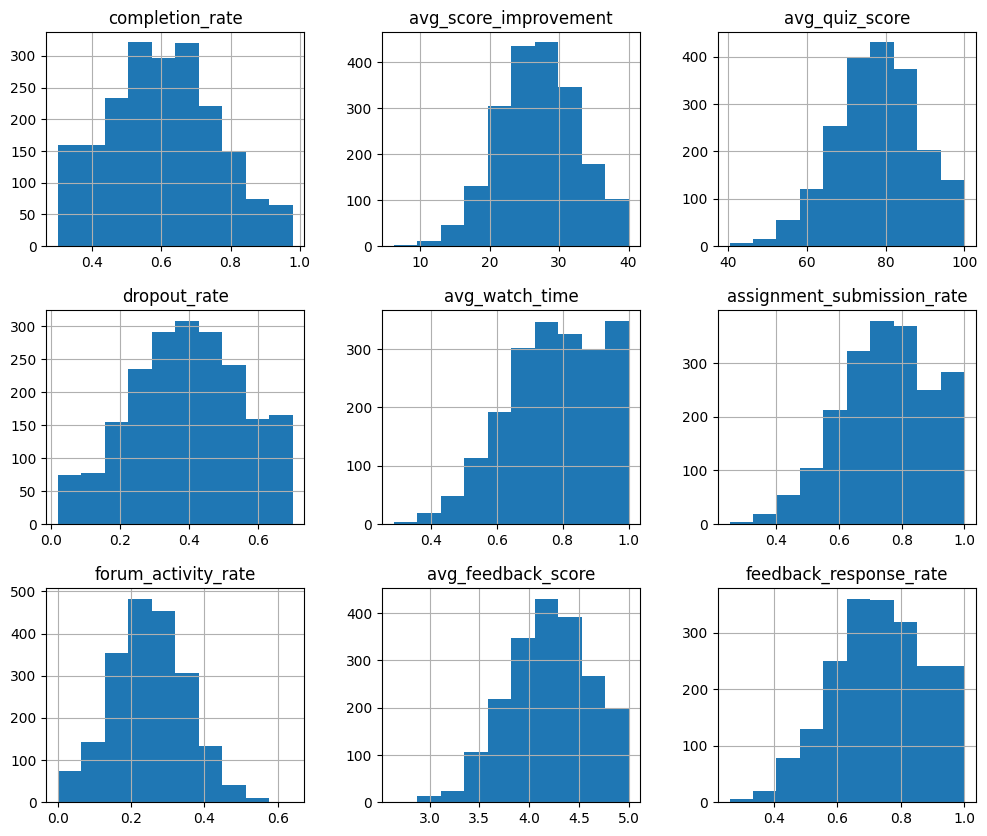

In [10]:


df.hist(figsize=(12,10))
plt.show()

KEY INSIGHTS


*   Most learner metrics show positive engagement and performance.
*  Average quiz scores are high, typically between 70%–85%.

*   Watch time and assignment submission rates peak around 80%, indicating strong participation.
*  Feedback scores cluster between 4.0–4.5, reflecting high learner satisfaction.

*   Completion rate is healthy at around 60%, though some batches show higher dropout risk.
*  Completion rate is healthy at around 60%, though some batches show higher dropout risk.

*   Forum activity is relatively low (10%–30%), indicating limited community interaction












### Correlation Analysis

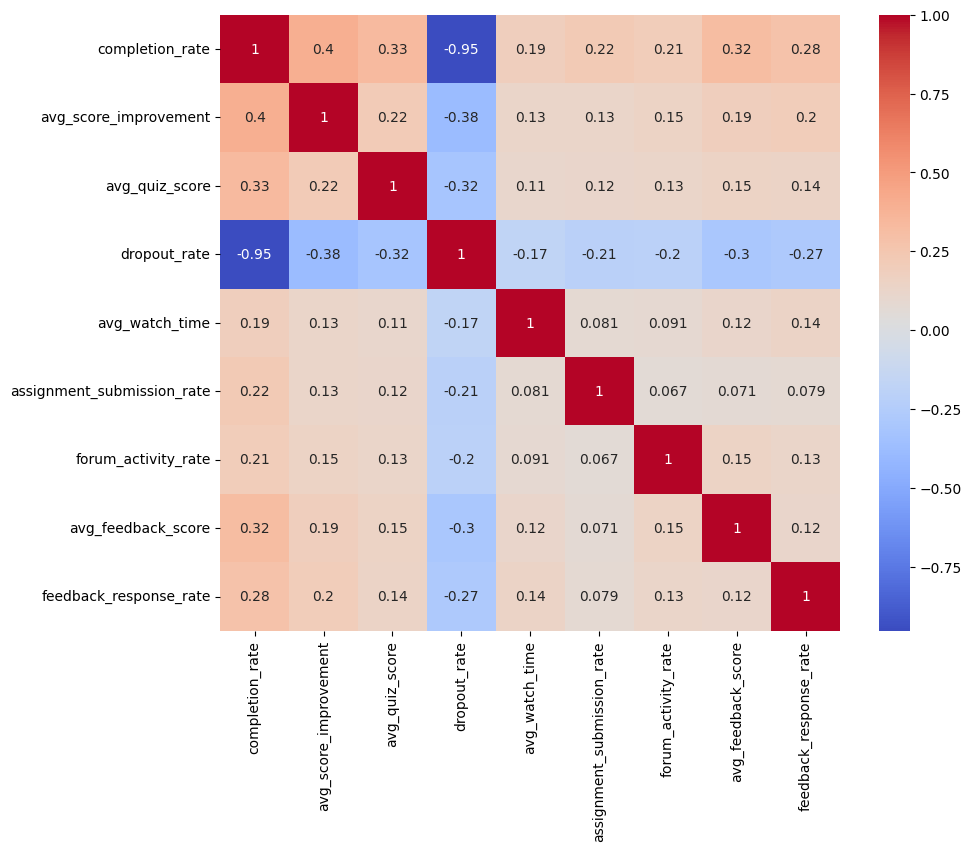

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

KEY INSIGHTS


*   Completion Rate vs Dropout Rate shows a very strong negative correlation (-0.95), indicating that higher dropout directly reduces course completion.
*   Score Improvement (0.40) has a moderate positive correlation with completion, suggesting that learners who see progress are more likely to finish the course.

*   Quiz Scores (0.33) and Feedback Scores (0.32) also positively relate to completion, highlighting the importance of both performance and learner satisfaction.
*  Assignment Submission Rate (0.22) and Forum Activity (0.21) show weak correlations, suggesting limited influence on course completion

*  Average Watch Time (0.19) has a very low correlation, indicating that passive video consumption alone does not strongly predict course completion








### Engagement vs Completion

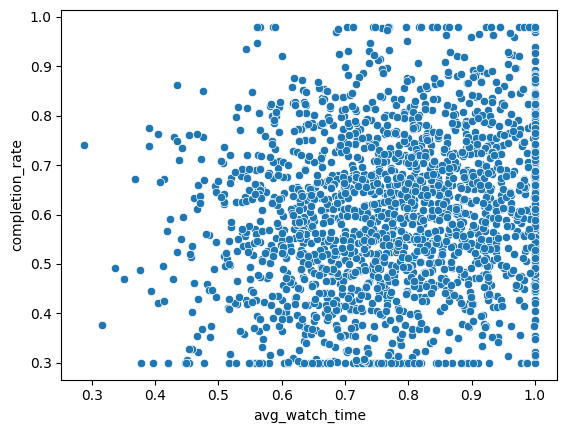

In [12]:
sns.scatterplot(x="avg_watch_time", y="completion_rate", data=df)
plt.show()

KEY INSIGHTS


*   Weak Positive Relationship: There is a slight positive relationship between watch time and completion rate, but the relationship is weak, confirming the low correlation (~0.19)
*  Passive Watcher Pattern: A dense cluster of users shows high watch time but low completion, suggesting many learners consume content but do not finish course requirements.

*   Efficient Completers: Some learners achieve high completion with moderate watch time, indicating they focus on key tasks like assignments and assessments.
*   Minimum Engagement Threshold: Very few learners with watch time below 40% reach high completion, implying a minimum level of content consumption is necessary.

*   Course completion appears to depend more on performance in assignments and quizzes rather than simply watching video content.








### Course Performance Comparision

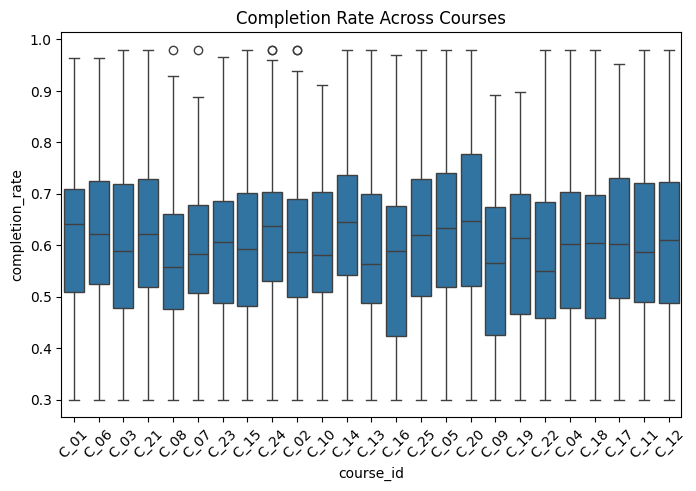

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x="course_id", y="completion_rate", data=df)
plt.xticks(rotation=45)
plt.title("Completion Rate Across Courses")
plt.show()

KEY INSIGHTS


*   Most courses show a median completion rate between 55%–65%, indicating fairly consistent learner performance across courses.
*  Completion rates range widely from about 30% to nearly 100%, showing significant variation in student outcomes within each course.

*   C_20 shows one of the highest completion levels, suggesting stronger learner performance.
*   C_16 and C_22 have comparatively lower median completion rates, indicating slightly weaker outcomes.

*   Some courses such as C_16, C_20, and C_09 show greater variability in student performance, while others like C_24 and C_10 appear more consistent.








## Instructor Effectiveness Score

In [16]:
df["effectiveness_score"] = (
    0.25 * df["completion_rate"] +
    0.20 * (1 - df["dropout_rate"]) +
    0.20 * df["avg_score_improvement"] +
    0.15 * (df["avg_quiz_score"] / 100) +
    0.20 * (df["avg_feedback_score"] / 5)
)
df[["instructor_id", "effectiveness_score"]].head()

,instructor_id,effectiveness_score
0,I_044,3.251675
1,I_119,5.169476
2,I_050,3.612544
3,I_024,5.462329
4,I_001,6.770056


EXPLANATION

This code creates a new column called effectiveness_score in the DataFrame df. The score measures overall instructor effectiveness by combining multiple performance metrics using weighted averages.



*   0.25 * completion_rate – Gives 25% weight to the course completion rate, indicating that higher completion reflects better instructor effectiveness.
*  0.20 * (1 - dropout_rate) – Uses 1 minus dropout rate so that lower dropouts increase the effectiveness score. It contributes 20% weight.

*   0.20 * avg_score_improvement – Adds 20% weight to the improvement in learner scores, capturing how much students progress during the course.
*   0.15 * (avg_quiz_score / 100) – Quiz scores are divided by 100 to normalize them to a 0–1 scale, and contribute 15% weight to the final score.

*  0.20 * (avg_feedback_score / 5) – Feedback scores are divided by 5 to normalize them to a 0–1 scale, contributing 20% weight based on learner satisfaction.








Overall, the formula combines completion, retention, learning improvement, academic performance, and student feedback to compute a balanced effectiveness score for each instructor.

## Effectiveness Tiers

In [18]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

df["effectiveness_tier"].value_counts()

,count
effectiveness_tier,
Low,667
High,667
Medium,666


Tier distribution (Low / Medium / High)


*   The dataset is almost perfectly balanced, with around one-third of observations in each tier, avoiding class imbalance.
*   The distribution suggests quantile-based categorization, where the dataset is divided into top, middle, and bottom thirds.

*   Such balanced tiers are useful for comparative analysis and machine learning models.
*  The tier labels are relative to the dataset, meaning the “Low” group represents the lowest third rather than poor absolute performance.




## Aggregate Data to Instructor Level

In [24]:
instructor_df = df.groupby("instructor_id").agg({
    "completion_rate":"mean",
    "dropout_rate":"mean",
    "avg_score_improvement":"mean",
    "avg_quiz_score":"mean",
    "avg_watch_time":"mean",
    "assignment_submission_rate":"mean",
    "forum_activity_rate":"mean",
    "avg_feedback_score":"mean",
    "feedback_response_rate":"mean",
    "effectiveness_score":"mean"
}).reset_index()

instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

print(instructor_df[["instructor_id", "effectiveness_score", "effectiveness_tier"]])

    instructor_id  effectiveness_score effectiveness_tier
0           I_001             5.857206             Medium
1           I_002             6.662854               High
2           I_003             6.641096               High
3           I_004             5.067111                Low
4           I_005             7.200363               High
..            ...                  ...                ...
115         I_116             5.754282             Medium
116         I_117             6.290315             Medium
117         I_118             7.208427               High
118         I_119             5.595787                Low
119         I_120             5.783153             Medium

[120 rows x 3 columns]


KEY INSIGHTS



*   The mean() aggregation function is used to calculate the average of each metric for every instructor. This provides a fair overall representation of instructor performance since instructors may teach multiple batches.
*  Averaging helps reduce batch-level fluctuations, ensuring that unusually high or low batch results do not overly influence the instructor’s overall performance.

*   Metrics such as completion rate, quiz score, and feedback score are continuous numerical variables, making the mean an appropriate summary statistic for comparison.
*  Instructors with few batches may have less reliable performance estimates due to limited data, so it may be useful to flag them or apply a minimum batch threshold.

*  Instructors with many batches provide more stable and reliable averages, offering stronger evidence of consistent teaching effectiveness.









## Prepare Data for Machine Learning

In [25]:
X = instructor_df.drop(["instructor_id","effectiveness_tier"], axis=1)

y = instructor_df["effectiveness_tier"]

## Train-Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Machine Learning Model

In [28]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Prediction

In [29]:
y_pred = model.predict(X_test)

EXPLANATION


*   RandomForestClassifier(random_state=42) is used to create the Random Forest classification model with a fixed random seed for reproducible results.
*   The model learns patterns from the training dataset using multiple decision trees built from the input features.

* After training, model.predict(X_test) is used to generate predictions on unseen test data.  
*   The predicted values are stored in y_pred, representing the model’s predicted effectiveness tier for each record

*   These predictions can then be compared with the actual values to evaluate the model’s performance and accuracy.







## Model Evaluation

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         9
         Low       1.00      1.00      1.00         8
      Medium       1.00      1.00      1.00         7

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



KEY INSIGHTS


*   The model achieved 100% accuracy (1.0), meaning all test samples were classified correctly.
*   Precision, recall, and F1-score are 1.00 for all classes (High, Medium, Low), indicating perfect classification performance for each effectiveness tier.

*   The model correctly predicted 9 High, 8 Low, and 7 Medium instructors without any misclassification.
*  While this indicates excellent performance, such perfect results may also suggest the possibility of overfitting or a very well-separated dataset, so further validation with more data may be useful.




### Confusion matrix

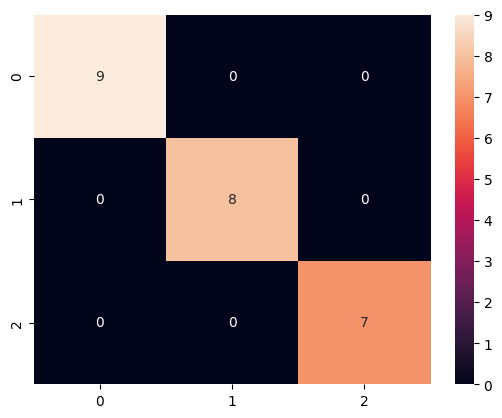

In [31]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

KEY INSIGHTS


*  The confusion matrix shows perfect classification, where all predictions fall on the diagonal (9, 8, 7), meaning every instance was correctly predicted.
*  There are no misclassifications, as all off-diagonal values are 0, indicating the model did not confuse any class with another.

*  The model correctly predicted 9 High, 8 Low, and 7 Medium instances, matching the actual class distribution in the test set.
*   This result supports the 100% accuracy, precision, recall, and F1-score obtained during model evaluation, indicating excellent model performance on the test data.





## Feature Importance

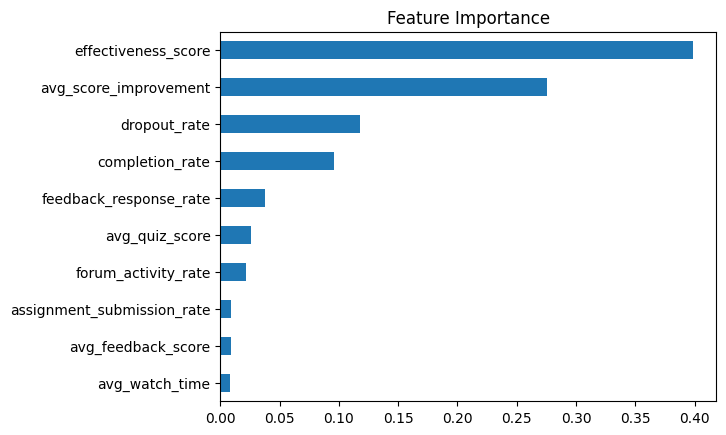

In [32]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

KEY INSIGHTS


*   Effectiveness_score is the most influential feature in the model, contributing the highest importance to predicting instructor effectiveness tiers.
*   Avg_score_improvement is the second most important factor, indicating that learner progress strongly influences instructor effectiveness.

*   Dropout_rate and completion_rate also play a notable role, showing that learner retention and course completion are key indicators of instructor performance.
*   Other features such as feedback_response_rate, quiz score, and forum activity have smaller contributions, suggesting they have less impact on the final prediction.

*   Avg_watch_time and avg_feedback_score have the lowest importance, meaning they contribute minimally to the model’s decision-making.








### Final Interpretation

The analysis shows that effectiveness_score is the most important factor influencing instructor effectiveness, followed by average score improvement, dropout rate, and completion rate. Instructors who help students improve their scores, keep dropout rates low, and maintain higher completion rates tend to be more effective.

In simple terms, instructors are considered effective when students learn more, stay engaged in the course, and successfully complete it. These factors reflect both student learning progress and engagement.

In an EdTech platform, these insights can be used to identify high-performing instructors and recognize effective teaching methods. The platform can also flag instructors with high dropout rates or low improvement scores, enabling targeted support, training, or content improvements to enhance overall course quality.

## Mandatory Analysis Questions

1. Which features most influenced instructor effectiveness, and why?









The most influential features are:


*   Effectiveness Score – the strongest predictor, as it summarizes overall instructor impact.
*   Average Score Improvement – shows how much learners progress, motivating completion.

*   Dropout Rate – lower dropout reflects better engagement and retention.
*  Completion Rate – higher course completion indicates effective teaching.

Interpretation: Instructors are most effective when students learn more, stay engaged, and successfully complete the course. These features capture both learning progress and engagement.






---





2.  Which variables could be misleading or confounded?






*   Average Watch Time – weak correlation with completion; high watch time doesn’t guarantee students finish.
*   Forum Activity Rate – low impact on completion, despite social engagement often being assumed important.

*   Assignment Submission Rate – weak predictor; submitting assignments alone doesn’t ensure course success.
*   Small Batch Instructors – metrics based on few batches may not be reliable, potentially skewing effectiveness scores.

Interpretation: Some metrics may appear important but don’t strongly influence actual student outcomes, so they should be interpreted cautiously.



---







3. How could this model fail in real-world usage?


*  Overfitting – perfect accuracy on the test set may not generalize to new data.

*   Limited features – the model relies on existing engagement and performance metrics, missing factors like course difficulty or external learner constraints.
*   Small sample sizes – instructors with few batches may get misclassified.


*   Dynamic behavior – learner engagement patterns may change over time, reducing model reliability.


---





4. What additional data would you want to improve this analysis?


*   Learner demographic information (age, background, prior knowledge)

*   Time spent on assignments or quizzes beyond videos
*   Peer interaction metrics and collaboration data


*   Course difficulty or complexity level

*   Instructor experience, teaching style, or credentials

Purpose: These can help capture more nuanced influences on instructor effectiveness and reduce confounding factors.


---






5. Should this model be used for instructor performance evaluation? Why or why not?
Not directly.


*   Pros: Provides insights into which instructors tend to drive better learner outcomes; helps identify high- and low-performing instructors.
*  Cons: Performance is relative, not absolute; small batch instructors may be misclassified; model may not generalize to new courses or cohorts; overreliance could overlook qualitative teaching aspects.

Recommendation: Use this model as a supporting tool rather than the sole criterion for performance evaluation, combining it with qualitative feedback and peer reviews.



## Conclusion

This analysis evaluated instructor effectiveness using learner engagement and performance metrics. Key factors such as effectiveness score, average score improvement, dropout rate, and completion rate were identified as the strongest indicators of teaching impact. The Random Forest model successfully classified instructors into Low, Medium, and High effectiveness tiers, providing insights into performance patterns.

While the model demonstrates high predictive accuracy, real-world application should combine these insights with qualitative feedback and additional contextual data to ensure fair and comprehensive instructor evaluation. Overall, the project highlights how data-driven analysis can support instructor assessment, optimize course delivery, and enhance learner outcomes in an EdTech setting.